#과제목표: LSTM을 적용해 뉴스 기사의 진위(fake/Real)를 분류
텍스트전처리-> 시퀀스변환-> 임베딩-> LSTM 학습-> 평가

#1.데이터 불러오기

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
USE_TITLE_ONLY = False    # True로 바꾸면 제목만 사용
MAX_VOCAB = 40000         # 토큰 사전 크기
MAX_LEN = 300             # 시퀀스 최대 길이(제목+본문이면 300~500 권장)
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 6

In [5]:
df_fake = pd.read_csv('/content/drive/MyDrive/Fake.csv')   # cols: title, text, subject, date
df_true = pd.read_csv('/content/drive/MyDrive/True.csv')

#2.데이터 전처리

In [6]:
print(df_fake.head())
print(df_true.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [7]:
print('총 샘플의 수(가짜) :',len(df_fake))
print('총 샘플의 수(진짜) :',len(df_true))

총 샘플의 수(가짜) : 23481
총 샘플의 수(진짜) : 21417


In [8]:
df_fake["label"] = 1  # Fake=1
df_true["label"] = 0   # Real=0

In [9]:
print(df_fake.columns)
print(df_true.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


In [10]:
df = pd.concat([df_fake, df_true], ignore_index=True)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

In [11]:
# df 전체 비율 출력 함수
def print_df_label_ratio(df):
    y = df["label"]
    total = len(y)
    counts = y.value_counts()

    print("\n------ 전체 데이터(df) 라벨 비율 ------")
    for label, cnt in counts.items():
        percent = round(cnt / total * 100, 3)
        if label == 0:
            print(f"진짜 기사(0): {percent}%")
        elif label == 1:
            print(f"가짜 기사(1): {percent}%")
        else:
            print(f"{label}: {percent}%")

# 호출
print_df_label_ratio(df)


------ 전체 데이터(df) 라벨 비율 ------
가짜 기사(1): 52.299%
진짜 기사(0): 47.701%


In [12]:
#제목과 본문을 합쳐 하나의 input으로/ title+text 모두 사용
def build_input_text(row):
    title = str(row.get("title", ""))
    text  = str(row.get("text", ""))
    if USE_TITLE_ONLY:
        return title
    # 제목 + 본문 합치되 너무 길면 본문 앞부분만 사용
    text = text[:4000]  # 안전 차단 (과도한 길이 방지)
    return (title + " [SEP] " + text).strip()

df["input_text"] = df.apply(build_input_text, axis=1)

In [13]:
# (간단 정제) 소문자화 정도만. 한글 쓸 때는 형태소기반 전처리 별도 고려
#df["input_text"] = df["input_text"].str.lower()

# 결측/공백 행 제거
df = df[(df["input_text"].notnull()) & (df["input_text"].str.strip() != "")]
df = df.reset_index(drop=True)

In [14]:
stop_words = set(stopwords.words('english'))

#(소문자화 -> 토큰화 -> 불용어 제거)
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]  # 알파벳만 남기기, stop word에 안들어간것만 리턴
    return tokens

df["tokens"] = df["input_text"].apply(preprocess)

In [15]:
# ---------------------------
# 3) Train/Val/Test 분할
# ---------------------------
X = df["input_text"].values
y = df["label"].values.astype(int)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
)

print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))

Train/Val/Test sizes: 35918 4490 4490


In [16]:
def print_label_ratio(name, y):
    # numpy array → pandas Series 변환
    y_s = pd.Series(y)
    total = len(y_s)
    counts = y_s.value_counts()

    print(f"\n------ {name} 라벨 비율 ------")
    for label, cnt in counts.items():
        percent = round(cnt / total * 100, 3)
        if label == 0:
            print(f"진짜 기사(0): {percent}%")
        elif label == 1:
            print(f"가짜 기사(1): {percent}%")
        else:
            print(f"{label}: {percent}%")

# 출력
print_label_ratio("훈련 데이터 (Train)", y_train)
print_label_ratio("검증 데이터 (Validation)", y_val)
print_label_ratio("테스트 데이터 (Test)", y_test)



------ 훈련 데이터 (Train) 라벨 비율 ------
가짜 기사(1): 52.3%
진짜 기사(0): 47.7%

------ 검증 데이터 (Validation) 라벨 비율 ------
가짜 기사(1): 52.294%
진짜 기사(0): 47.706%

------ 테스트 데이터 (Test) 라벨 비율 ------
가짜 기사(1): 52.294%
진짜 기사(0): 47.706%


##2.1 시퀀스 변환

In [17]:
print(X_train[:5])

['Trump asks Supreme Court to block travel ban ruling [SEP] WASHINGTON (Reuters) - The U.S. Justice Department on Friday asked the Supreme Court to block a judge’s ruling that prevented President Donald Trump’s travel ban from being applied to grandparents of U.S. citizens and refugees already being processed by resettlement agencies. In a court filing, the administration asked the justices to overturn Thursday’s decision by a U.S. district judge in Hawaii, which limited the scope of the administration’s temporary ban on refugees and travelers from six Muslim-majority countries. The latest round in the fight over Trump’s March 6 executive order, which he says is needed for national security reasons, came after the Supreme Court intervened last month to partially revive the two bans, which were blocked by lower courts. The Supreme Court said then that the ban could take effect, but that people with a “bona fide relationship” to a U.S. person or entity could not be barred.  The administr

In [23]:
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

In [24]:
#토크나이저 생성
tokenizer = Tokenizer(vocab_size)
tokenizer.fit_on_texts(X_train)

#정수 시퀀스로 변환
X_train_encoded = tokenizer.texts_to_sequences(X_train)
X_val_encoded = tokenizer.texts_to_sequences(X_val)
X_test_encoded = tokenizer.texts_to_sequences(X_test)
print(X_train_encoded[:5])

[[12, 2267, 462, 128, 2, 1364, 785, 481, 636, 40, 109, 64, 1, 32, 8, 277, 189, 9, 207, 216, 1, 462, 128, 2, 1364, 4, 8980, 636, 7, 4312, 34, 65, 168, 785, 481, 25, 115, 4267, 2, 7386, 3, 32, 8, 611, 5, 515, 311, 115, 10086, 20, 3418, 760, 6, 4, 128, 2904, 1, 156, 216, 1, 2465, 2, 5739, 8880, 287, 20, 4, 32, 8, 784, 426, 6, 3399, 54, 2079, 1, 4666, 3, 1, 2716, 2112, 481, 9, 515, 5, 4479, 25, 635, 291, 435, 286, 1, 651, 2158, 6, 1, 519, 66, 168, 422, 567, 412, 257, 54, 13, 147, 11, 772, 10, 133, 122, 1535, 356, 47, 1, 462, 128, 7461, 99, 255, 2, 6251, 4994, 1, 94, 4094, 54, 49, 1821, 20, 1017, 1569, 1, 462, 128, 14, 161, 7, 1, 481, 87, 175, 1444, 33, 7, 45, 16, 4, 19742, 11599, 12810, 2, 4, 32, 8, 478, 51, 5795, 87, 23, 22, 3581, 1, 156, 44, 6203, 7183, 7, 1458, 188, 1, 481, 37, 2408, 2, 7386, 5, 86, 302, 261, 3847, 1, 59, 3, 3399, 2, 1036, 3399, 382, 32, 8, 784, 426, 14029, 4784, 2, 2417, 1, 4085, 3, 29, 87, 22, 1700, 13, 1426, 10, 1, 59, 623, 9, 208, 6, 1, 128, 2904, 1, 277, 189, 14, 1

In [25]:
#시퀀스 패딩
X_train_padded = pad_sequences(X_train_encoded, maxlen = MAX_LEN)
X_val_padded = pad_sequences(X_val_encoded, maxlen = MAX_LEN)
X_test_padded = pad_sequences(X_test_encoded, maxlen = MAX_LEN)

In [26]:
print("훈련 데이터의 크기(shape):", X_train_padded.shape)

훈련 데이터의 크기(shape): (35918, 300)


#3.모델 생성

In [27]:
from tensorflow.keras.layers import Embedding, Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [29]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN))
model.add(LSTM(LSTM_UNITS))
model.add(Dense(1, activation='sigmoid'))

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train_padded, y_train, epochs=EPOCHS, callbacks=[es, mc], batch_size=BATCH_SIZE, validation_data=(X_val_padded, y_val))

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - acc: 0.8939 - loss: 0.2463
Epoch 1: val_acc improved from -inf to 0.94477, saving model to best_model.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 471s 828ms/step - acc: 0.8940 - loss: 0.2462 - val_acc: 0.9448 - val_loss: 0.1476
Epoch 2/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - acc: 0.9751 - loss: 0.0814
Epoch 2: val_acc improved from 0.94477 to 0.97951, saving model to best_model.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 451s 802ms/step - acc: 0.9751 - loss: 0.0814 - val_acc: 0.9795 - val_loss: 0.0661
Epoch 3/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - acc: 0.9847 - loss: 0.0500
Epoch 3: val_acc did not improve from 0.97951
562/562 ━━━━━━━━━━━━━━━━━━━━ 455s 810ms/step - acc: 0.9847 - loss: 0.0500 - val_acc: 0.9771 - val_loss: 0.0698
Epoch 4/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - acc: 0.9896 - loss: 0.0350
Epoch 4: val_acc improved from 0.97951 to 0.98330, saving model to best_model.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 463s 824ms/step - acc: 0.9896 - loss: 0.0350 - val_acc: 0.9833 - val_loss: 0.0528
Epoch 5/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - acc: 0.9927 - loss: 0.0269
Epoch 5: val_acc did not improve from 0.98330
562/562 ━━━━━━━━━━━━━━━━━━━━ 462s 822ms/step - acc: 0.9927 - loss: 0.0269 - val_acc: 0.9759 - val_loss: 0.0662
Epoch 6/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - acc: 0.9946 - loss: 0.0181
Epoch 6: val_acc improved from 0.98330 to 0.99176, saving model to best_model.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 458s 815ms/step - acc: 0.9946 - loss: 0.0181 - val_acc: 0.9918 - val_loss: 0.0294


In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,503,428 (40.07 MB)

 Trainable params: 5,251,713 (20.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,251,715 (20.03 MB)

In [31]:
with open("model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

#4.성능 평가

In [37]:
#1>저장된 모델 불러오기
from tensorflow.keras.models import load_model

# ModelCheckpoint로 저장했던 best_model.h5 불러오기
best_model = load_model('best_model.h5')

In [38]:
#2> 테스트 데이터 예측 (y_pred_proba, y_pred)
# 확률 예측 (sigmoid라서 0~1 확률)
y_pred_proba = best_model.predict(X_test_padded)

# 0.5 기준으로 이진 라벨로 변환
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 175ms/step


In [39]:
#3> 평가지표 계산 (Accuracy, AUC, Precision, Recall, F1, Confusion Matrix)
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)

# AUC (ROC-AUC)
auc = roc_auc_score(y_test, y_pred_proba)

# Precision / Recall / F1
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("=== Test 성능 지표 ===")
print(f"Accuracy : {acc:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["Real(0)", "Fake(1)"]))

print("\n[Confusion Matrix]")
print(cm)


=== Test 성능 지표 ===
Accuracy : 0.9906
AUC      : 0.9995
Precision: 0.9906
Recall   : 0.9915
F1-score : 0.9911

[Classification Report]
              precision    recall  f1-score   support

     Real(0)       0.99      0.99      0.99      2142
     Fake(1)       0.99      0.99      0.99      2348

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490


[Confusion Matrix]
[[2120   22]
 [  20 2328]]


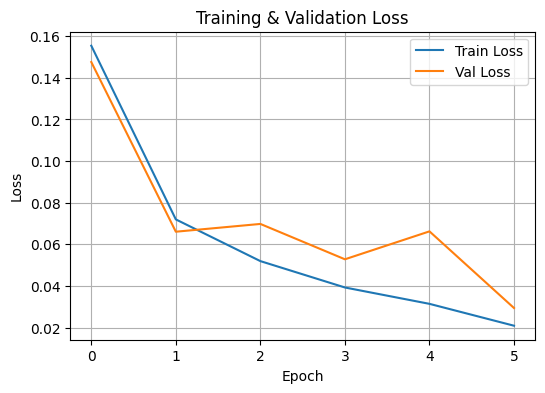

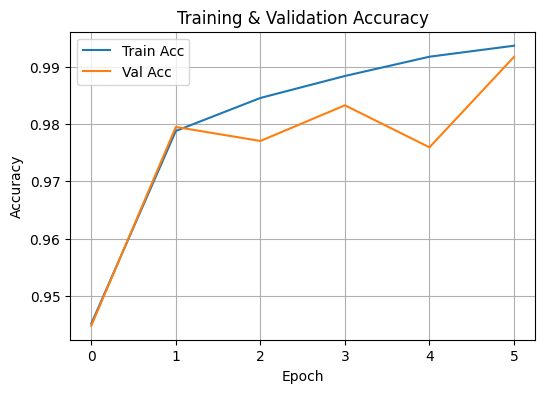

In [41]:
#4> 학습 곡선 시각화 (Loss / Accuracy)
# 1) Loss 학습 곡선
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Accuracy 학습 곡선
plt.figure(figsize=(6,4))
plt.plot(history.history['acc'], label='Train Acc')
plt.plot(history.history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


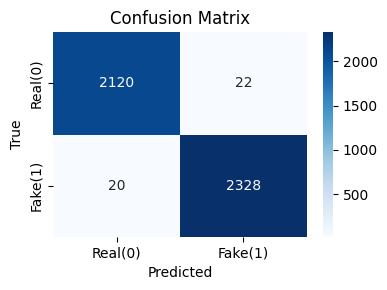

In [43]:
#5> Confusion Matrix Heatmap 시각화
plt.figure(figsize=(4,3))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Real(0)', 'Fake(1)'],
            yticklabels=['Real(0)', 'Fake(1)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#5.예제 테스트

In [45]:
#1> 샘플 10개 추출
# 테스트 데이터 DataFrame 만들기 (텍스트 + 라벨)
df_test = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

# 진짜/가짜 각각 5개씩 추출
samples_fake = df_test[df_test["label"] == 1].sample(5)
samples_real = df_test[df_test["label"] == 0].sample(5)

samples = pd.concat([samples_fake, samples_real]).sample(10)  # 섞기

In [46]:
#2> 모델이 예측하도록 함수 만들기
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    proba = best_model.predict(pad)[0][0]
    pred = 1 if proba >= 0.5 else 0
    return pred, proba

In [47]:
#3> 결과 표 만들기
results = []

for _, row in samples.iterrows():
    text = row["text"]
    true_label = row["label"]
    pred_label, prob = predict_text(text)

    results.append({
        "뉴스 제목": text[:50] + "...",
        "예측": "Fake" if pred_label == 1 else "Real",
        "실제": "Fake" if true_label == 1 else "Real",
        "결과": "✔" if pred_label == true_label else "✖"
    })

df_results = pd.DataFrame(results)
df_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


,뉴스 제목,예측,실제,결과
0,Russia risks decades of low growth under U.S. ...,Real,Real,✔
1,Detained Reuters journalist wrote children's b...,Real,Real,✔
2,Trump Friend Alex Jones Just Challenged Alec B...,Fake,Fake,✔
3,"BOOM! TED CRUZ, DESANTIS PUSH For Term Limits:...",Fake,Fake,✔
4,Lunatic MSNBC Reporter: “A paper trail leads d...,Fake,Fake,✔
5,Exclusive: Republicans mostly blame Congress f...,Real,Real,✔
6,Thousands of Romanians protest ruling party's ...,Real,Real,✔
7,WATCH EPIC VIDEO Of Truth Teller Colonel Ralph...,Fake,Fake,✔
8,BETTY WON’T BITE! Watch What Happens When Kati...,Fake,Fake,✔
9,"Clinton, Sanders both say they can beat Trump ...",Real,Real,✔


#6.모델 개선 실험
Dropout적용/ 하이퍼파라미터 변경/

##6.1 Dropout 적용

In [52]:
# ---------------------------
# Dropout 적용한 LSTM 모델
# ---------------------------

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# EarlyStopping (너가 원래 쓰던 변수명)
es = EarlyStopping(monitor='val_loss', mode='min', patience=4, verbose=1)

# 저장 경로
dropout_ckpt = ModelCheckpoint(
    'best_model_dropout.h5',
    monitor='val_acc',
    mode='max',
    verbose=1,
    save_best_only=True
)

# Dropout 적용 모델 정의
def build_dropout_model():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=EMBED_DIM,
                        input_length=MAX_LEN))

    model.add(LSTM(
        LSTM_UNITS,
        dropout=0.3,
        recurrent_dropout=0.3
    ))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['acc']
    )

    return model


# 모델 생성
dropout_model = build_dropout_model()
dropout_model.summary()

# 학습
history_dropout = dropout_model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    callbacks=[es, dropout_ckpt]   # ← 여기 수정 완료!
)

print("\n=== Dropout 모델 테스트 성능 ===")
best_dropout_model = load_model('best_model_dropout.h5')
y_pred_proba_d = best_dropout_model.predict(X_test_padded)
y_pred_d = (y_pred_proba_d >= 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred_d))
print("AUC      :", roc_auc_score(y_test, y_pred_proba_d))
print("Precision:", precision_score(y_test, y_pred_d))
print("Recall   :", recall_score(y_test, y_pred_d))
print("F1-score :", f1_score(y_test, y_pred_d))


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8852 - loss: 0.2787
Epoch 1: val_acc improved from -inf to 0.96860, saving model to best_model_dropout.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 633s 1s/step - acc: 0.8853 - loss: 0.2785 - val_acc: 0.9686 - val_loss: 0.1020
Epoch 2/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9722 - loss: 0.0908
Epoch 2: val_acc improved from 0.96860 to 0.97439, saving model to best_model_dropout.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - acc: 0.9722 - loss: 0.0908 - val_acc: 0.9744 - val_loss: 0.0774
Epoch 3/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9782 - loss: 0.0712
Epoch 3: val_acc did not improve from 0.97439
562/562 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - acc: 0.9782 - loss: 0.0712 - val_acc: 0.9619 - val_loss: 0.0997
Epoch 4/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9842 - loss: 0.0555
Epoch 4: val_acc improved from 0.97439 to 0.98530, saving model to best_model_dropout.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - acc: 0.9842 - loss: 0.0555 - val_acc: 0.9853 - val_loss: 0.0455
Epoch 5/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9882 - loss: 0.0444
Epoch 5: val_acc did not improve from 0.98530
562/562 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - acc: 0.9882 - loss: 0.0444 - val_acc: 0.9849 - val_loss: 0.0449
Epoch 6/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9887 - loss: 0.0420
Epoch 6: val_acc did not improve from 0.98530
562/562 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - acc: 0.9887 - loss: 0.0420 - val_acc: 0.9849 - val_loss: 0.0436

=== Dropout 모델 테스트 성능 ===


141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step
Accuracy : 0.9830734966592427
AUC      : 0.997637101405014
Precision: 0.9850555081127241
Recall   : 0.9825383304940375
F1-score : 0.9837953091684435


In [55]:
cm = confusion_matrix(y_test, y_pred_d)
cm

array([[2107,   35],
       [  41, 2307]])

In [56]:
print(classification_report(y_test, y_pred_d, target_names=["Real(0)", "Fake(1)"]))

              precision    recall  f1-score   support

     Real(0)       0.98      0.98      0.98      2142
     Fake(1)       0.99      0.98      0.98      2348

    accuracy                           0.98      4490
   macro avg       0.98      0.98      0.98      4490
weighted avg       0.98      0.98      0.98      4490



##6.2 하이퍼파라미터 변경

In [57]:
# ---------------------------
# 하이퍼파라미터 변경 모델
# ---------------------------

# ModelCheckpoint
hp_ckpt = ModelCheckpoint(
    'best_model_hp.h5',
    monitor='val_acc',
    mode='max',
    verbose=1,
    save_best_only=True
)

# 하이퍼파라미터 변경 모델 정의
def build_hp_model():
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ))
    model.add(LSTM(64))          # LSTM 유닛 변경
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',         # optimizer 변경
        loss='binary_crossentropy',
        metrics=['acc']
    )
    return model


# 모델 생성
hp_model = build_hp_model()
hp_model.summary()

# 학습
history_hp = hp_model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=32,                 # batch size 변경
    validation_data=(X_val_padded, y_val),
    callbacks=[es, hp_ckpt]
)

# ---------------------------
# 성능 지표 계산
# ---------------------------
print("\n=== 하이퍼파라미터 변경 모델 테스트 성능 ===")

best_hp_model = load_model('best_model_hp.h5')

y_pred_proba_hp = best_hp_model.predict(X_test_padded)
y_pred_hp = (y_pred_proba_hp >= 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred_hp))
print("AUC      :", roc_auc_score(y_test, y_pred_proba_hp))
print("Precision:", precision_score(y_test, y_pred_hp))
print("Recall   :", recall_score(y_test, y_pred_hp))
print("F1-score :", f1_score(y_test, y_pred_hp))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

1123/1123 ━━━━━━━━━━━━━━━━━━━━ 287s 256ms/step - acc: 0.9791 - loss: 0.0637 - val_acc: 0.9844 - val_loss: 0.0525
Epoch 3/6
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - acc: 0.9362 - loss: 0.1856
Epoch 3: val_acc improved from 0.98441 to 0.98686, saving model to best_model_hp.h5


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 284s 253ms/step - acc: 0.9362 - loss: 0.1855 - val_acc: 0.9869 - val_loss: 0.0478
Epoch 4/6
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - acc: 0.9964 - loss: 0.0146
Epoch 4: val_acc improved from 0.98686 to 0.99287, saving model to best_model_hp.h5


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 323s 254ms/step - acc: 0.9964 - loss: 0.0146 - val_acc: 0.9929 - val_loss: 0.0245
Epoch 5/6
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - acc: 0.9987 - loss: 0.0049
Epoch 5: val_acc did not improve from 0.99287
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 283s 252ms/step - acc: 0.9987 - loss: 0.0049 - val_acc: 0.9918 - val_loss: 0.0292
Epoch 6/6
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - acc: 0.9995 - loss: 0.0022
Epoch 6: val_acc improved from 0.99287 to 0.99421, saving model to best_model_hp.h5


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 322s 253ms/step - acc: 0.9995 - loss: 0.0022 - val_acc: 0.9942 - val_loss: 0.0211



=== 하이퍼파라미터 변경 모델 테스트 성능 ===
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
Accuracy : 0.9906458797327394
AUC      : 0.999325269574042
Precision: 0.9893887945670629
Recall   : 0.9927597955706985
F1-score : 0.9910714285714286


In [60]:
cm = confusion_matrix(y_test, y_pred_hp)
cm

array([[2117,   25],
       [  17, 2331]])

In [59]:
print(classification_report(y_test, y_pred_hp, target_names=["Real(0)", "Fake(1)"]))

              precision    recall  f1-score   support

     Real(0)       0.99      0.99      0.99      2142
     Fake(1)       0.99      0.99      0.99      2348

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



##6.3 LSTM 층 구성

In [61]:
# ---------------------------
# 스택드 LSTM 모델 정의
# ---------------------------
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def build_stacked_lstm():
    model = Sequential()
    model.add(Embedding(vocab_size, EMBED_DIM, input_length=MAX_LEN))
    model.add(LSTM(128, return_sequences=True))  # 1층 LSTM
    model.add(LSTM(64))                          # 2층 LSTM
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

# ---------------------------
# 콜백 설정 (EarlyStopping + ModelCheckpoint)
# ---------------------------
es_stacked = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=4,
    verbose=1
)

stacked_ckpt = ModelCheckpoint(
    'best_model_stacked.h5',
    monitor='val_acc',   # metrics=['acc'] 이므로 val_acc 모니터링
    mode='max',
    verbose=1,
    save_best_only=True
)

# ---------------------------
# 모델 학습
# ---------------------------
stacked_model = build_stacked_lstm()
stacked_model.summary()

history_stacked = stacked_model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    callbacks=[es_stacked, stacked_ckpt]
)

# ---------------------------
# 최적 모델 로드 및 성능 평가
# ---------------------------
print("\n=== Stacked LSTM 모델 테스트 성능 ===")

best_stacked_model = load_model('best_model_stacked.h5')

y_pred_proba_s = best_stacked_model.predict(X_test_padded)
y_pred_s = (y_pred_proba_s >= 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred_s))
print("AUC      :", roc_auc_score(y_test, y_pred_proba_s))
print("Precision:", precision_score(y_test, y_pred_s))
print("Recall   :", recall_score(y_test, y_pred_s))
print("F1-score :", f1_score(y_test, y_pred_s))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

562/562 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/step - acc: 0.8755 - loss: 0.2838 - val_acc: 0.9710 - val_loss: 0.0931
Epoch 2/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9776 - loss: 0.0719
Epoch 2: val_acc improved from 0.97105 to 0.98731, saving model to best_model_stacked.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - acc: 0.9776 - loss: 0.0719 - val_acc: 0.9873 - val_loss: 0.0432
Epoch 3/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9877 - loss: 0.0423
Epoch 3: val_acc improved from 0.98731 to 0.98886, saving model to best_model_stacked.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - acc: 0.9877 - loss: 0.0423 - val_acc: 0.9889 - val_loss: 0.0375
Epoch 4/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9886 - loss: 0.0383
Epoch 4: val_acc did not improve from 0.98886
562/562 ━━━━━━━━━━━━━━━━━━━━ 738s 1s/step - acc: 0.9886 - loss: 0.0383 - val_acc: 0.9800 - val_loss: 0.0547
Epoch 5/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9934 - loss: 0.0220
Epoch 5: val_acc improved from 0.98886 to 0.98931, saving model to best_model_stacked.h5


562/562 ━━━━━━━━━━━━━━━━━━━━ 692s 1s/step - acc: 0.9934 - loss: 0.0220 - val_acc: 0.9893 - val_loss: 0.0374
Epoch 6/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9944 - loss: 0.0191
Epoch 6: val_acc did not improve from 0.98931
562/562 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - acc: 0.9944 - loss: 0.0191 - val_acc: 0.9891 - val_loss: 0.0381

=== Stacked LSTM 모델 테스트 성능 ===


141/141 ━━━━━━━━━━━━━━━━━━━━ 36s 215ms/step
Accuracy : 0.989532293986637
AUC      : 0.9994474507577024
Precision: 0.9864693446088795
Recall   : 0.9936115843270868
F1-score : 0.9900275832802886


In [62]:
cm = confusion_matrix(y_test, y_pred_s)
cm

array([[2110,   32],
       [  15, 2333]])

In [63]:
print(classification_report(y_test, y_pred_s, target_names=["Real(0)", "Fake(1)"]))

              precision    recall  f1-score   support

     Real(0)       0.99      0.99      0.99      2142
     Fake(1)       0.99      0.99      0.99      2348

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490

